# About the Random Sampling

It is sometimes useful to generate a sample of random variables following an experimental distribution, that may (or not) have an explicit analytical definition. The purpose of this exercise is to explore different techniques used to produce suc random samples.

In [1]:
# M2 Statistics project 2024
# date : 2024/11/01
# Author : Giamello Giulio

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import minimize
from scipy.stats import logistic, norm, uniform
import statistics

## $\text{I}$ - Using the reciprocal of the cumulative distribution.

Let's assume that the cumulative function of the target distribution, $\mathscr{F}_{\mathrm{x}}$, is known or, at least, that it can be numerically derived from the experimental data. To generate a random sample of independent random variables $\mathrm{x}$, identically distributed according to the density function with cumulative $\mathscr{F}_{\mathrm{x}}$, we can use a transformation of the continuous *uniform* distribution in the range $[0,1]$, $\mathrm{U} \sim \mathbb{I}_{[0,1]}$, that has the property to coincide with its own reciprocal: $\text{P}(\mathrm{U}<p) = \mathscr{F}_{\mathrm{U}}(p) = p = \mathscr{F}_{\mathrm{u}}^{-1}(p)$. The *inverse sampling method* is based on the reciprocal theorem that ensures that given the reciprocal function $Q_{\mathrm{x}}(p) = \mathscr{F}_{\mathrm{u}}^{-1}(p)$, the random variable defined as $\mathrm{x} = Q_{\mathrm{x}}(\mathrm{U})$ has $\mathscr{F}_{\mathrm{x}}(x)$ for cumulative.

For the purpose of this exercise, let's consider for instance the *sigmoid* function, defined as:

$$
\mathscr{F}_{\mathrm{x}}(x;\lambda) = \frac{1}{1+e^{-\lambda x}}
$$

with parameter $\lambda \in \mathbb{R^+}$. This monotonically increasing function, $\mathscr{F}_{\mathrm{x}}:x \in \mathbb{R} \rightarrow \mathscr{F}_{\mathrm{x}}(x;\lambda) \in [0,1]$ is a valid and normalized *cumulative distribution function* (CDF) for a continuous random variable $\mathrm{x}$. It's easy to derive the corresponding reciprocal function, i.e. the *percent point (or quantile) function* (PPF) of the distribution:

$$
\mathscr{F}_{\mathrm{x}}(x;\lambda) =
\text{P}(\mathrm{x}<x) = p \Rightarrow x =
\mathscr{Q}_{\mathrm{x}}(p;\lambda) =
\mathscr{F}_{\mathrm{x}}^{-1}(p;\lambda) =
\frac{1}{\lambda}\ln \left(\frac{p}{1-p}\right)
$$

### $\text{I.1}$ 

Generate a sample of $N = 10^5$ random probabilities $p_k$, uniformly distributed in $[0, 1]$. For each random value $p_k$, evaluate the corresponding value $x_k = \mathscr{F}_{\mathrm{x}}^{-1}(p_k; \lambda = 1) = \ln \left(\frac{p_k}{1-p_k}\right)$.

In [3]:
# 'N' number of random probabilities
N = 10**5

# 'p' vector of size N filled with random uniform probabilities 'np.random.uniform'
p = np.random.uniform(10**(-8),1,N)  # '(10**(-8)' and not '0' to avoid division by zero (NaN)

In [4]:
# 'x' vector of size N filled with 'np.log(p/(1-p))'
x = np.log(p/(1-p))

Draw the density histogram of the sample $\{x_k\}$.

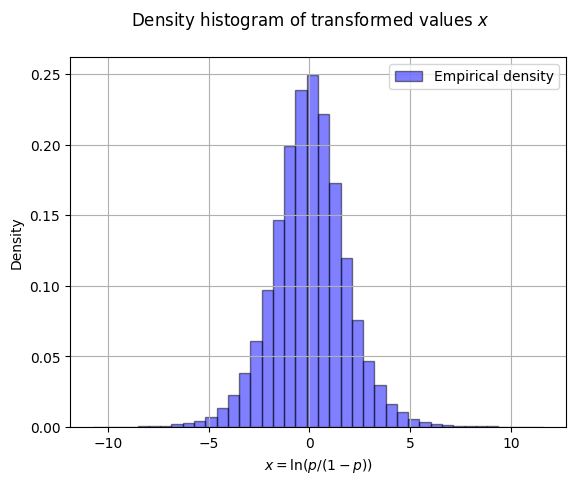

In [5]:
# define the plot
fig, ax = plt.subplots()

# plot the histogram
ax.hist(x, bins=40, density=True, label='Empirical density', color='blue', edgecolor='black', alpha=0.5)

# set x-axis label
ax.set_xlabel('$x = $ln$(p / (1 - p))$')

# set y-axis label
ax.set_ylabel('Density')

# impose legend position
ax.legend(loc='upper right')

# plot grid
ax.grid()

# insert plot title
fig.suptitle('Density histogram of transformed values $x$')

# show plot
plt.show()


You now have a random sample of values $\mathrm{x} \sim f_{\mathrm{x}}(x; \lambda = 1)$, for the parameter value $\lambda = 1$.

### $\text{I.2}$ 

It is rather easy to derive the explicit expression of the *probability density function* (PDF):

$$
f_{\mathrm{x}}(x; \lambda) =
\frac{\partial \mathscr{F}_{\mathrm{x}}(x;\lambda)}{\partial x} = \frac{\lambda}{4}\mathrm{sech}^2 \left( \frac{\lambda x}{2} \right)
$$

where $\mathrm{sech}(z) = \frac{1}{\mathrm{cosh}(z)}$ is the *hyperbolic secant*.

In [6]:
# define the PDF
def pdf(x, l):
    return (l/4)*(1/(np.cosh((l*x)/2)**2))

Superimpose the $f_{\mathrm{x}}(x; 1)$ density curve on the sample histogram. Does it match?

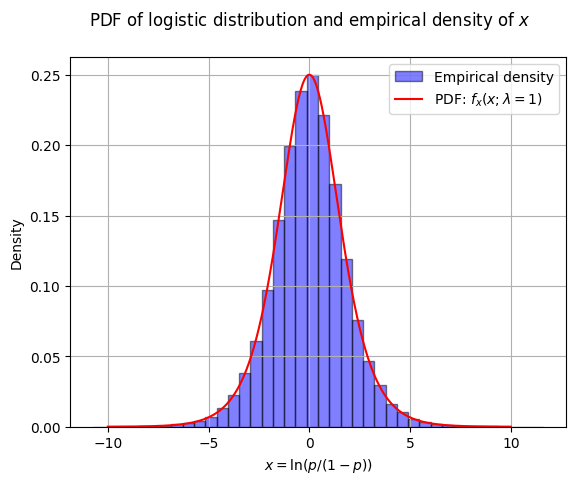

In [7]:
# 'x_axis' variable for the x-axis, the range is set looking at the histogma plotted before
x_axis = np.linspace(-10,10,10**3)

# superimpose the pdf(x,1) curve on the histogram
ax.plot(x_axis,pdf(x_axis,1), label='PDF: $f_x(x; $'r'$\lambda$''$=1)$', color = 'r')

# impose legend position
ax.legend(loc='upper right')

# insert plot title
fig.suptitle('PDF of logistic distribution and empirical density of $x$')

# show the updated figure of before
fig

# WARNING: run this cell only one time, otherwise it will superimpose again the function,
# adding another entry in the legend.

The superimposed *probability density function* (PDF) matches with the sample histogram.

### $\text{I.3}$ 

To further validate the generated distribution, let's estimate the $\lambda$ parameter of the theoretical PDF using the Maximum Likelihood (ML) method. Define the negative log-likelihood function of the parameter $\lambda$, evaluated on your sample $\{x_k\}$:

$$
-\ln \mathscr{L}(\lambda;\{x_k\}) = - \sum_{k=1}^{N} \ln[f_{\mathrm{x}}(x_k; \lambda)]
$$

and extract the ML estimator $\hat{\lambda}$ that mimimizes this function.

In [8]:
# define the ML
def nlog_likelihood(l, x):
    return -np.sum(np.log(pdf(x, l)))

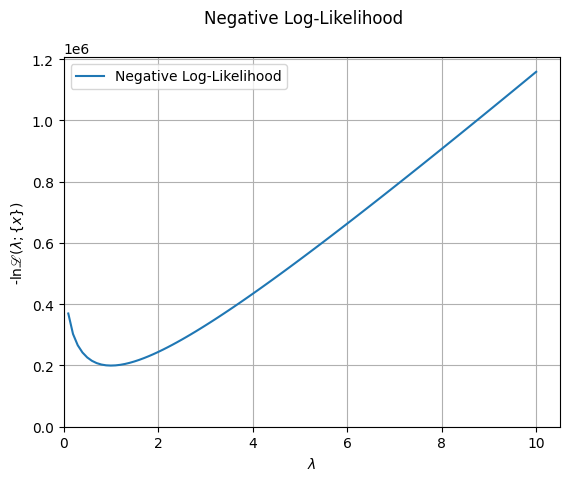

In [9]:
# plot of Negative Log-Likelihood to find "by eye" an approximation
# of the minimum, to choose the x0 for the minimizer

# define the plot
fig, ax = plt.subplots()

# 'x_axis' variable for the x-axis
x_axis = np.linspace(0.1,10,10**2)

# evaluate the ML function for each value x_k varying the lamba parameter
y = [nlog_likelihood(g, x) for g in x_axis]

# plot the ML function in [0.1, 10]
ax.plot(x_axis, y, label='Negative Log-Likelihood')

# set x-axis label
ax.set_xlabel(r'$\lambda$')

# set y-axis label
ax.set_ylabel('-ln'r'$\mathscr{L}$''$($'r'$\lambda$'r'$;\{x\})$')

# impose legend position
ax.legend(loc='upper left')

# set x-axis limit
ax.set_xlim(left=0)

# set y-axis limit
ax.set_ylim(bottom=0)

# plot grid
ax.grid()

# insert plot title
fig.suptitle('Negative Log-Likelihood')

# show plot
plt.show()

In [10]:
# 'x0' initial guess for lambda
x0 = 1.3

# Ensure lambda > 0
res = minimize(nlog_likelihood, x0, args = x, bounds=[(10**(-8), None)])

# 'ext_x' x-axis point where the ML function is minimal
ext_x = (res.x)[0]

# 'ext_fun' y-axis value (minimum) of ML function in the 'ext_x' point 
ext_fun = res.fun

# print the 'ext_x' and the 'ext_fun' values
print('λ = %.4f' % ext_x)
print('Negative Log-Likelihood = %.4f' % ext_fun)

λ = 1.0035
Negative Log-Likelihood = 199690.2939


### $\text{I.4}$ 

Evaluate the corresponding uncertainty $\hat{\sigma_{\lambda}}$, using the graphical $\Delta \ln \mathscr{L}(\lambda_{\pm}) = \frac{1}{2}$ method. Is the value measured on the sample, $\hat{\lambda} \pm \hat{\sigma_{\lambda}}$, consistent with the expected value of the theoretical PDF, $\lambda = 1$?

In [11]:
# initialize 'lb_min' and 'lb_plu' variables to find σ_λ+ and σ_λ-
lb_plu = 0
lb_min = 0

# step to increase 'lb_min' and 'lb_plu'
step = 0.00001

# while loops to find σ_λ+ and σ_λ- such that 'a'='b'=0.5
a = 0
while a < 0.5:
    lb_plu += step
    a = nlog_likelihood(ext_x+lb_plu,x)-ext_fun
        
b = 0
while b < 0.5:
    lb_min += step
    b = nlog_likelihood(ext_x-lb_min,x)-ext_fun

In [12]:
# print the obtained values for σ_λ+ and σ_λ-
print('σ_λ+ = %.4f' % lb_plu)
print('σ_λ- = %.4f' % lb_min)

σ_λ+ = 0.0027
σ_λ- = 0.0027


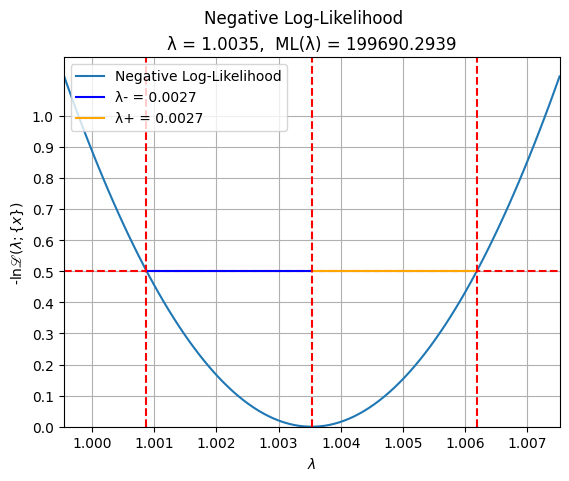

In [13]:
# plot of Negative Log-Likelihood around the minumum and extimation
# of sigma_{lambda} by graphical method

# define the plot
fig, ax = plt.subplots()

# 'x_axis' variable for the x-axis
x_axis = np.linspace(ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu,10**2)

# evaluate the ML function for each value x_k varying the lamba parameter
y = [nlog_likelihood(g, x) for g in x_axis]

# plot the ML function in [ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu]
ax.plot(x_axis, y-ext_fun, label='Negative Log-Likelihood')

# set x-axis label
ax.set_xlabel(r'$\lambda$')

# set y-axis label
ax.set_ylabel('-ln'r'$\mathscr{L}$''$($'r'$\lambda$'r'$;\{x\})$')

# set x-axis limit
ax.set_xlim(ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu)

# set y-axis limit
ax.set_ylim(bottom=0)

# set y-axis ticks
ax.set_yticks(np.linspace(0, 1, 11))

# set horizontal line at y=0.5
ax.axhline(y=0.5, color='r', linestyle='--')

# total width of the x-axis
s=((3/2)*lb_plu)+((3/2)*lb_min)

# position of 'ext_x-lb_min' and 'ext_x+lb_plu' scaled respect to 's'
x_axis_min=(lb_min)/(2*s)
x_axis_max=(lb_plu+((3/2)*lb_min))/(s)

# set horizontal lines for 'lb_min' and 'lb_plu'
ax.axhline(y=0.5, xmin=x_axis_min, xmax=0.5, color='b', linestyle='-', label='λ- = %.4f' % lb_min)
ax.axhline(y=0.5, xmin=0.5, xmax=x_axis_max, color='orange', linestyle='-', label='λ+ = %.4f' % lb_plu)

# set vertical line at x=ext_x-lb_min
ax.axvline(x=ext_x-lb_min, color='r', linestyle='--')

# set vertical line at x=ext_x
ax.axvline(x=ext_x, color='r', linestyle='--')

# set vertical line at x=ext_x+lb_plu
ax.axvline(x=ext_x+lb_plu, color='r', linestyle='--')

# plot grid
ax.grid()

# impose legend position
ax.legend(loc='upper left')

# insert plot title
title = 'λ = %.4f,  ML(λ) = %.4f' % (ext_x, ext_fun)
plt.title(title)
fig.suptitle('Negative Log-Likelihood')

# show plot
plt.show()

The value measured on the sample, $\hat{\lambda} \pm \hat{\sigma_{\lambda}}$, is consistent with the expected value of the theoretical PDF, $\lambda = 1$.

### $\text{I.5}$

If yes, congratulations! You can now generate a random sample from any CDF. However, you have worked for nothing but the glory, because this sech-squared PDF is well-known and already implemented in the *scipy* library under the name of *logistic distribution*, with all the usual machinery for random generation, evaluation of the PDF, CDF, PPF, log-Likelihood ...
Produce an alternative sample of $N$ random values according to the *logistic* density with the *scipy* generator (scipy.stats.logistic.rvs(size=N)). Compare this sample distribution with your own sampling generation, by plotting the *residuals histogram*, i.e. the histogram of the difference in each *bin* of the two histograms, divided by the associated uncertainty. You can approximate the uncertainty on the *bin* content with $\sigma_{n_i} \simeq \sqrt{n_i}$ (be careful with the density normalisation). Conclusion.

In [14]:
# generate a logistic distributed sample 
sample = logistic.rvs(0,1,size=N)

In [15]:
# select the 'down' and 'up' as the min and max value between
# both the manual generated 'x' distribution and the 'sample' one 
down = min(min(x),min(sample))
up = max(max(x),max(sample))

In [16]:
# create 'myBin' to set the same binning for both histograms
myBin = np.linspace(down, up, 40)

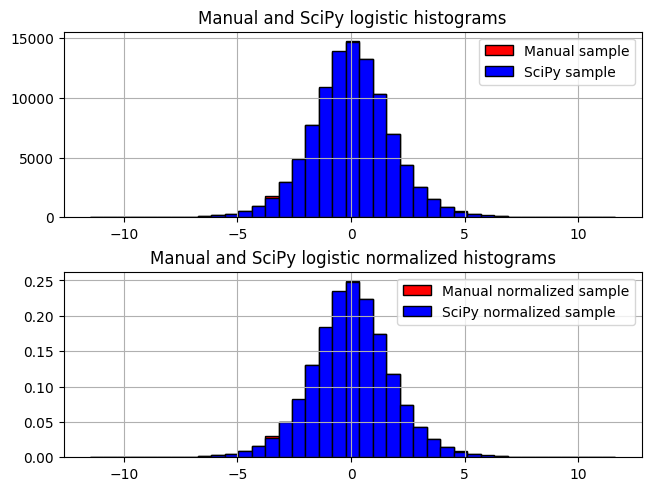

In [17]:
# define the plot
# (layout='constrained' to avoid plot title overlap) 
fig, ax = plt.subplots(2,1, layout='constrained')

# plot the histograms
bin_data = ax[0].hist(x, bins=myBin, density=False, label='Manual sample', color='r', edgecolor='black', alpha=1)
bin_samp = ax[0].hist(sample, bins=myBin, density=False, label='SciPy sample', color='b', edgecolor='black', alpha=1)

# plot the normalized histogram
bin_data_nomr = ax[1].hist(x, bins=myBin, density=True, label='Manual normalized sample', color='r', edgecolor='black', alpha=1)
bin_samp_norm = ax[1].hist(sample, bins=myBin, density=True, label='SciPy normalized sample', color='b', edgecolor='black',alpha=1)

# insert plot title
ax[0].set_title('Manual and SciPy logistic histograms')
ax[1].set_title('Manual and SciPy logistic normalized histograms')

# impose legend position
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')

# plot grid
ax[0].grid()
ax[1].grid()

# show plot
plt.show()

In [18]:
# 'residuals' and 'residuals_norm' the residuals between manual and
# SciPy logistic samples, divided by the approximated bins uncertainty
residuals = []
residuals_norm = []
for i in range(len(bin_data[0])):
    
    if bin_samp[0][i]==0:
        residuals.append(0)
    else:
        residuals.append((bin_data[0][i]-bin_samp[0][i])/np.sqrt(bin_samp[0][i]))
        
    if bin_samp_norm[0][i]==0:
        residuals_norm.append(0)
    else:
        residuals_norm.append((bin_data_nomr[0][i]-bin_samp_norm[0][i])/np.sqrt(bin_samp_norm[0][i]))

residuals = np.array(residuals)
residuals_norm = np.array(residuals_norm)

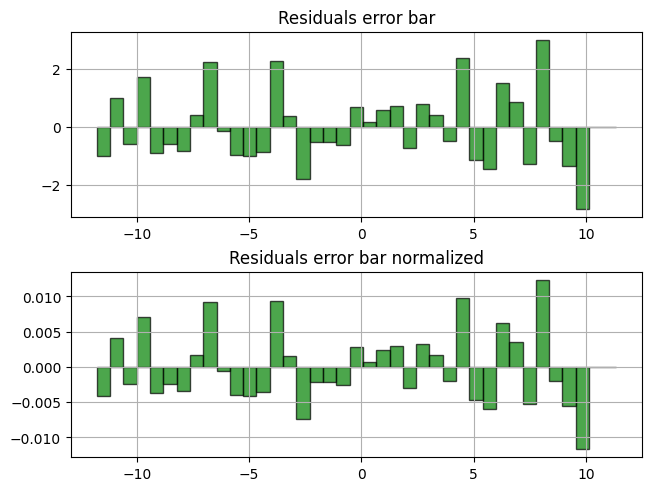

In [19]:
# define the plot
fig, ax = plt.subplots(2,1, layout='constrained')

# plot the error bars
ax[0].bar(myBin[:-1], residuals, width=np.diff(myBin), color='g', edgecolor='black', alpha=0.7)
ax[1].bar(myBin[:-1], residuals_norm, width=np.diff(myBin), color='g', edgecolor='black', alpha=0.7)

# insert plot title
ax[0].set_title('Residuals error bar')
ax[1].set_title('Residuals error bar normalized')

# plot grid
ax[0].grid()
ax[1].grid()

# show plot
plt.show()

Conclusion: for $40$ bins, the residiual error is $\sim 2$ or $3$ entries for bin at maximum.

### $\text{I.6}$

The *logistic* density exhibits a symmetrical profile with fatter tails than the Gaussian-Normal distribution (these kind of profiles are known as *leptokurtic*). The Expectation and the Variance of the *logistic* distribution, $\mathrm{x} \sim f_{\mathrm{x}}(x;\lambda)$, are:

$$
\mathbb{E}[\mathrm{x}]=0 \quad \text{and} \quad \mathbb{V}[\mathrm{x}]=\frac{\pi^2}{3\lambda^2}
$$

Let's try to play with this known Variance to evaluate the number $\pi$.
Use the random sample $\{x_k\}$, generated with the parameter value $\lambda = 1$, to build a new sample $\{z_k\}$, where the random variable $z$ is the standardized $\mathrm{x}$ value scaled by the factor $\frac{1}{\sqrt{3}}$, i.e.

$$
z_k=\frac{x_k-\overline{\mu_x}}{\sqrt{3\overline{\sigma_x}^2}}
$$

with $\overline{\mu_x}$ and $\overline{\sigma_x}^2$, the mean and the variance of the sample $\{x_k\}$, respectively. In the limit of large $N$, the sample variance approximates the distribution Variance, $overline{\sigma_x}^2 \simeq \mathbb{V}[\mathrm{x}]$. The Variance of the rescaled variable $\mathrm{z}$ is then $\mathbb{V}[\mathrm{x}] \simeq \frac{1}{3}$ and its PDF is a *logistic* distribution, $f_{\mathrm{z}}(z;\lambda_{\mathrm{z}})$ with $\lambda_{\mathrm{z}} = \pi$.
Repeat questions $\text{I.3}$ and $\text{I.4}$ to evaluate the ML estimator $\hat{\lambda_{\mathrm{z}}}$ that minimizes the negative log-Likelihood function, $-\ln \mathscr{L}(\lambda;\{z_k\})$, evaluated on the rescaled sample $\{z_k\}$, and the associated uncertainty. Is it compatible with the known $\pi$ value? (you can also conclude that sampling methods are highly inefficient to determine a large number of digits of $\pi$ !)

In [20]:
# 'm' mean of sample x
m = statistics.mean(x)

# 's' variance of sample x
s = statistics.variance(x)

# 'z' generate rescaled sample 
z = (x-m)/(np.sqrt(3*s))

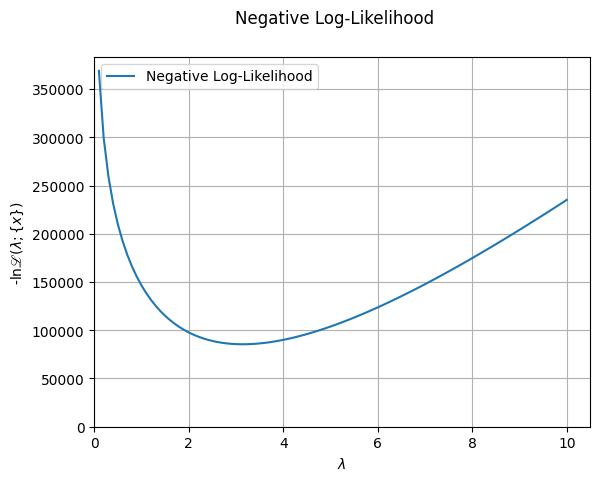

In [21]:
# plot of Negative Log-Likelihood to find "by eye" an approximation
# of the minimum, to choose the x0 for the minimizer

# define the plot
fig, ax = plt.subplots()

# 'x_axis' variable for the x-axis
x_axis = np.linspace(0.1,10,10**2)

# evaluate the ML function for each value x_k varying the lamba parameter
y = [nlog_likelihood(g, z) for g in x_axis]

# plot the ML function in [0.1, 10]
ax.plot(x_axis, y, label='Negative Log-Likelihood')

# set x-axis label
ax.set_xlabel(r'$\lambda$')

# set y-axis label
ax.set_ylabel('-ln'r'$\mathscr{L}$''$($'r'$\lambda$'r'$;\{x\})$')

# impose legend position
ax.legend(loc='upper left')

# set x-axis limit
ax.set_xlim(left=0)

# set y-axis limit
ax.set_ylim(bottom=0)

# plot grid
ax.grid()

# insert plot title
fig.suptitle('Negative Log-Likelihood')

# show plot
plt.show()

In [22]:
# 'x0' initial guess for lambda
x0 = 3

# Ensure lambda > 0
res = minimize(nlog_likelihood, x0, args = z, bounds=[(10**(-8), None)])

# 'ext_x' x-axis point where the ML function is minimal
ext_x = (res.x)[0]

# 'ext_fun' y-axis value (minimum) of ML function in the 'ext_x' point 
ext_fun = res.fun

# print the 'ext_x' and the 'ext_fun' values
print('λ = %.4f' % ext_x)
print('Negative Log-Likelihood = %.4f' % ext_fun)

λ = 3.1443
Negative Log-Likelihood = 85483.1600


In [23]:
# initialize 'lb_min' and 'lb_plu' variables to find σ_λ+ and σ_λ-
lb_plu = 0
lb_min = 0

# step to increase 'lb_min' and 'lb_plu'
step = 0.00001

# while loops to find σ_λ+ and σ_λ- such that 'a'='b'=0.5
a = 0
while a < 0.5:
    lb_plu += step
    a = nlog_likelihood(ext_x+lb_plu,z)-ext_fun
        
b = 0
while b < 0.5:
    lb_min += step
    b = nlog_likelihood(ext_x-lb_min,z)-ext_fun

In [24]:
# print the obtained values for σ_λ+ and σ_λ-
print('σ_λ+ = %.4f' % lb_plu)
print('σ_λ- = %.4f' % lb_min)

σ_λ+ = 0.0083
σ_λ- = 0.0083


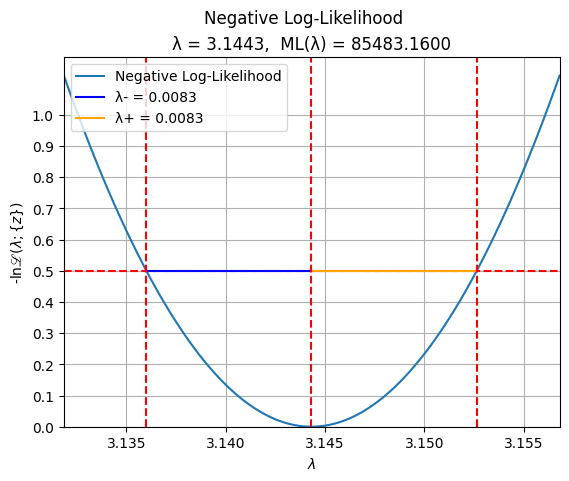

In [25]:
# plot of Negative Log-Likelihood around the minumum and extimation
# of sigma_{lambda} by graphical method

# define the plot
fig, ax = plt.subplots()

# 'x_axis' variable for the x-axis
x_axis = np.linspace(ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu,10**2)

# evaluate the ML function for each value x_k varying the lamba parameter
y = [nlog_likelihood(g, z) for g in x_axis]

# plot the ML function in [ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu]
ax.plot(x_axis, y-ext_fun, label='Negative Log-Likelihood')

# set x-axis label
ax.set_xlabel(r'$\lambda$')

# set y-axis label
ax.set_ylabel('-ln'r'$\mathscr{L}$''$($'r'$\lambda$'r'$;\{z\})$')

# set x-axis limit
ax.set_xlim(ext_x-(3/2)*lb_min,ext_x+(3/2)*lb_plu)

# set y-axis limit
ax.set_ylim(bottom=0)

# set y-axis ticks
ax.set_yticks(np.linspace(0, 1, 11))

# set horizontal line at y=0.5
ax.axhline(y=0.5, color='r', linestyle='--')

# total width of the x-axis
s=((3/2)*lb_plu)+((3/2)*lb_min)

# position of 'ext_x-lb_min' and 'ext_x+lb_plu' scaled respect to 's'
x_axis_min=(lb_min)/(2*s)
x_axis_max=(lb_plu+((3/2)*lb_min))/(s)

# set horizontal lines for 'lb_min' and 'lb_plu'
ax.axhline(y=0.5, xmin=x_axis_min, xmax=0.5, color='b', linestyle='-', label='λ- = %.4f' % lb_min)
ax.axhline(y=0.5, xmin=0.5, xmax=x_axis_max, color='orange', linestyle='-', label='λ+ = %.4f' % lb_plu)

# set vertical line at x=ext_x-lb_min
ax.axvline(x=ext_x-lb_min, color='r', linestyle='--')

# set vertical line at x=ext_x
ax.axvline(x=ext_x, color='r', linestyle='--')

# set vertical line at x=ext_x+lb_plu
ax.axvline(x=ext_x+lb_plu, color='r', linestyle='--')

# plot grid
ax.grid()

# impose legend position
ax.legend(loc='upper left')

# insert plot title
title = 'λ = %.4f,  ML(λ) = %.4f' % (ext_x, ext_fun)
plt.title(title)
fig.suptitle('Negative Log-Likelihood')

# show plot
plt.show()

In [26]:
# extimation of absolute percentage error between 'np.pi' and the extimated value lambda
print('Percentage absolute error between np.pi and the extimated value λ')
print('%.4f' % (np.abs(np.pi-ext_x)*100/np.pi))

Percentage absolute error between np.pi and the extimated value λ
0.0867


The obtained value for $\pi$ is compatible with the known $\pi$ value, with a percentage absolute error as the one up here.

## $\text{I}$ - The accept-reject sampling method.

The accept-reject method is a *Monte Carlo* technique that allows to "sculpt" a random sample for any target PDF, $g_{\mathrm{x}}(x)$, using a known reference density $f_{\mathrm{x}}(x)$ that verifies the criteria

$$
\alpha f_{\mathrm{x}}(x) \geq g_{\mathrm{x}}(x) \quad \forall x \in \text{supp}(g_{\mathrm{x}}(x))
$$

where $\alpha$ is a scaling constant that ensures that the inequality holds for all $x$.
This method works as follow:

1. generate one random probability $p$ uniformly distributed in $[0, 1]$;
2. generate one random $x$ value according to the known reference density $f_{\mathrm{x}}(x)$;
3. if the density ratio $\frac{g_{\mathrm{x}}(x)}{\alpha f_{\mathrm{x}}(x)} \geq p$ accept the value $x$ (else reject it);
4. repeat the procedure $N$ times.

The accept-reject method generally requires large reference samples, in particular to populate the low density regions of the target PDF. The closer the target and the reference shapes, the lower the rejection rate.

Let's try to generate a random sample of Normally-distributed events, using the latter *logistic* distribution as a reference.

### $\text{II.1}$

The maximum of the density function is $f_{\mathrm{x}}(0;1)=\frac{1}{4}$ for the *logistic* distribution, and $\mathcal{N}_{\mathrm{x}}(0;0,1)=\frac{1}{\sqrt{2}}$ for the *Normal* distribution. We can choose the minimal scaling factor as $\alpha_0 = \frac{4}{\sqrt{2\pi}}$ to ensure the *logistic* distribution wrap the *Normal* one for all $x$ values.

Draw the two functions, $\alpha_0 f_{\mathrm{x}}(0;1)$ and $\mathcal{N}_{\mathrm{x}}(0;0,1)$, on the same graph to verify that we have $\alpha_0 f_{\mathrm{x}}(0;1) \geq \mathcal{N}_{\mathrm{x}}(x) \quad \forall x$.

In [27]:
# 'a0' scaling factor
a0=4/np.sqrt(2*np.pi)

# 'N' number of random probabilities
N = 10**5

# 'v' quantiles to generate the following distributions
v = np.linspace(-10,10,N)

# 'sample_norm' generate normal pdf
sample_norm = norm.pdf(v,0,1)

# 'sample_log' generate logistic pdf
sample_log = logistic.pdf(v,0,1)

# 'wrap_log' generate wrapped logistic pdf
wrap_log = a0*sample_log

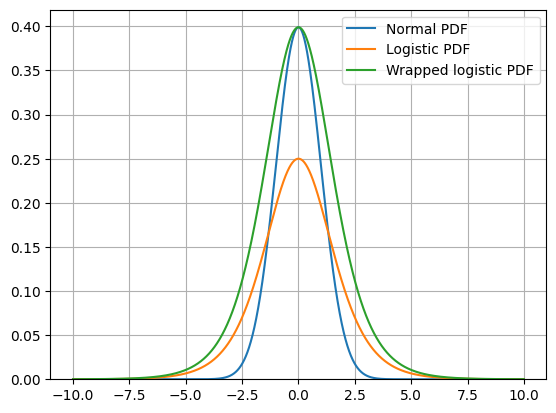

In [28]:
# define the plot
fig, ax = plt.subplots()

# plot normal pdf
ax.plot(v,sample_norm, label='Normal PDF')

# plot logistic pdf
ax.plot(v,sample_log, label='Logistic PDF')

# plot wrapped logistic pdf
ax.plot(v,wrap_log, label='Wrapped logistic PDF')

# generate legend
ax.legend()

# set y-axis limit
ax.set_ylim(bottom=0)

# plot grid
ax.grid()

# show plot
plt.show()

### $\text{II.2}$

For each event in the random *logistic* sample previously generated $\{x_k\}$, ($k=1$, $N$)
1. evaluate the ratio $r(x_k)=\frac{\mathcal{N}_{\mathrm{x}}(x_k)}{\alpha_0 f_{\mathrm{x}}(x_k;1)}$;
2. generate a random probability $p$ uniformly distributed in $[0,1]$;
3. if $r(x_k) \geq p$ save $x_k$ in the subsample of accepted values $\{x_k\}_a$, $m=1$, $M \leq N$.

What is the acceptance rate $\frac{M}{N}$?

In [29]:
# 's' vector of size N filled with random uniform probabilities 'np.random.uniform'
s = np.random.uniform(10**(-8),1,N) # '(10**(-8)' and not '0' to avoid division by zero (NaN)

# 'x' vector of size N filled with 'np.log(s/(1-s))'
x = np.log(s/(1-s))

In [30]:
# 'r' ratio between normal pdf and wrapped logistic pdf calculated on x values
r = (norm.pdf(x,0,1))/(a0*logistic.pdf(x,0,1))

# 'p' random probability variable uniformly distibuted in [0,1]
p = np.random.uniform(0,1,N)

In [31]:
# 'x_accepted' accepted values vector
x_accepted = x[r>=p]

In [32]:
# 'ratio' acceptance ratio
ratio = len(x_accepted)/len(x)

# print 'ratio' value
print('ratio: %.4f' % ratio)

ratio: 0.6253


### $\text{II.3}$

Draw the density histogram for the subsample $\{x_m\}_a$. Verify it exhibits the expected *Normal* profile by performing a fit of the Gaussian PDF to the $\{x_k\}_a$ subsample (use `scipy.stats.norm.fit`, for instance). Give the obtained $\hat{\mu}$ and $\hat{\sigma}$ fit values and draw the corresponding PDF, $\mathcal{N}(x;\hat{\mu},\hat{\sigma})$, on the histogram.

In [33]:
# perform normal fit of 'x_accepted' and extract 'mean' and 'sigma' values
mean, sigma = norm.fit(x_accepted)

# print 'mean' and 'sigma' values
print('μ = %.4f' % mean)
print('σ = %.4f' % sigma)

μ = -0.0038
σ = 0.9998


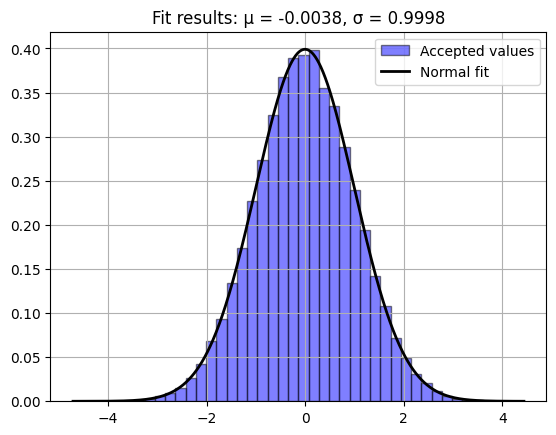

In [34]:
# define the plot
fig, ax = plt.subplots()

# plot the histogram
ax.hist(x_accepted, bins=40, density=True, label='Accepted values', color='blue', edgecolor='black', alpha=0.5)

# set x-axis limit
xmin = mean-5*sigma
xmax = mean+5*sigma
xmin, xmax = plt.xlim()

# 'h' variable for the x-axis
h = np.linspace(xmin, xmax, 1000)

# 'gauss' generate normal pdf
gauss = norm.pdf(h, mean, sigma)

# plot normal pdf
ax.plot(h, gauss, color='k', linewidth=2, label='Normal fit')

# insert plot title
plt.title('Fit results: μ = %.4f, σ = %.4f' % (mean, sigma))

# generate legend
ax.legend()

# plot grid
ax.grid()

# show plot
plt.show()

### $\text{II.4}$

While usually not the optimal choice, the *Uniform* distribution in the finite range $[a,b]$, which is wrapping any other distribution when a proper scaling is applied, can be used as the reference distribution to produce any random sample in a finite range.

Determine the optimal scalr factor $\alpha_0$ and produce a random *logistic* sample for $\mathrm{x}\sim f_{\mathrm{x}}(x;1)$ in the range $[-10,10]$ using an *Uniform* disribution as reference. What is the acceptance rate $\frac{M}{N}$? Try to find a better reference choice than the Uniform PDF.

In [35]:
# 'a0' scaling factor, it is setted =5 because if we want a function 
# uniform pdf equal to 1/20 in the range [-10,10] such that it is greater or equal to
# the logistic pdf for all x, we have to set a0=(1/20)**(-1)/4,
# where 1/4 is the maximum of logistic pdf
a0 = 5

# 'uni_dist' uniform distribution in the range [-10,10]
uni_dist = np.random.uniform(-10,10,N)

# 'sample_log' generate logistic pdf
sample_log = logistic.pdf(uni_dist,0,1)

# 'sample_uni' generate uniform pdf
sample_uni = uniform.pdf(uni_dist,-10,20)

# 'wrap_uni' generate wrapped uniform pdf
wrap_uni = a0*sample_uni

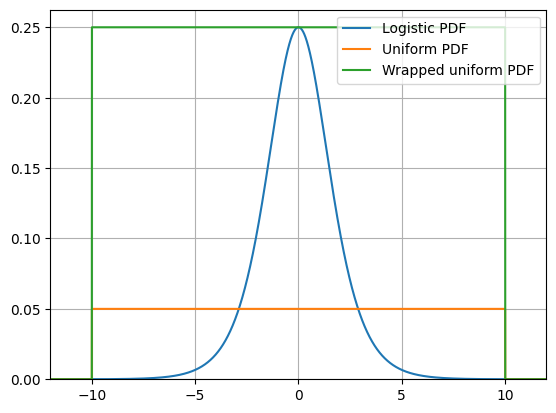

In [36]:
# define the plot
fig, ax = plt.subplots()

# set x-axis limits
xmin, xmax = plt.xlim((-12,12))

# 'xplot' variable for the x-axis
xplot = np.linspace(-12,12,N)

# plot logistic pdf
ax.plot(xplot,logistic.pdf(xplot,0,1), label='Logistic PDF')

# plot uniform pdf
ax.plot(xplot,uniform.pdf(xplot,-10,20), label='Uniform PDF')

# plot wrapped uniform pdf
ax.plot(xplot,a0*uniform.pdf(xplot,-10,20), label='Wrapped uniform PDF')

# impose legend position
ax.legend(loc='upper right')

# set y-axis limit
ax.set_ylim(bottom=0)

# plot grid
ax.grid()

# show plot
plt.show()

In [37]:
# 'r' ratio between logistic pdf and wrapped uniform pdf
r = (sample_log)/(wrap_uni)

In [38]:
# 'accepted' accepted values vector
accepted = uni_dist[r>=p]

In [39]:
# 'ratio' acceptance ratio
ratio = len(accepted)/len(uni_dist)

# print 'ratio' value
print('ratio: %.4f' % ratio)

ratio: 0.2023


In [40]:
# perform logistic fit of 'accepted' and extract 'p1' and 'p2' values
p1, p2 = logistic.fit(accepted)

# print 'p1' and 'p2' values
print('μ = %.4f' % p1)
print('σ = %.4f' % p2)

μ = -0.0190
σ = 0.9935


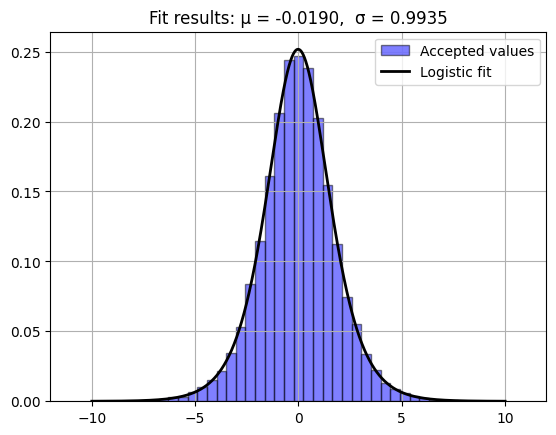

In [41]:
# define the plot
fig, ax = plt.subplots()

# plot the histogram
ax.hist(accepted, bins=40,  density=True, label='Accepted values', color='blue', edgecolor='black', alpha=0.5)

# set x-axis limit
xmin, xmax = plt.xlim((-12,12))

# 'h' variable for the x-axis
h = np.linspace(-10, 10, 1000)

# 'loplot' generate logistic pdf
loplot = logistic.pdf(h, p1, p2)

# plot logistic pdf
ax.plot(h, loplot, 'k', linewidth=2, label='Logistic fit')

# insert plot title
plt.title('Fit results: μ = %.4f,  σ = %.4f' % (p1, p2))

# generate legend
ax.legend()

# plot grid
ax.grid()

# show plot
plt.show()

Try to find a better reference choice than the Uniform PDF.

In [42]:
# while loop to find sigma value such that the wrapped normal pdf
# is greatrer or equal to the logistic pdf for all x values, with increasing
# step= 0.01
ok = False
std = 2
while ok==False:
    a0 = logistic.pdf(0,0,1)/norm.pdf(0,0,std)
    vec = (a0*norm.pdf(v,0,std))-logistic.pdf(v,0,1)
    if len(vec[vec<0])==0:
        ok=True
    else:
        std += 0.01
        
print('σ = %.4f' % std)

σ = 2.4100


In [43]:
# 'gau_dist' uniform distribution in the range [-10,10]
gau_dist = norm.rvs(0,std,size=N)

# 'sample_log' generate logistic pdf
sample_log = logistic.pdf(gau_dist,0,1)

# 'gau' generate normal pdf 
gau = norm.pdf(gau_dist,0,std)

# 'a0' scaling factor, it is setted equal to the ratio of the maximum of
# the logistic pdf and the normal pdf
a0 = logistic.pdf(0,0,1)/norm.pdf(0,0,std)

# 'wrap_gau' generate wrapped normal pdf
wrap_gau = a0*gau

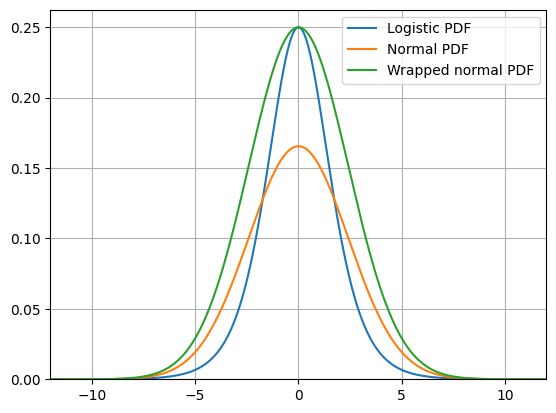

In [44]:
# define the plot
fig, ax = plt.subplots()

# set x-axis limit
xmin, xmax = plt.xlim((-12,12))

# plot logistic pdf
ax.plot(xplot,logistic.pdf(xplot,0,1), label='Logistic PDF')

# plot normal pdf
ax.plot(xplot,norm.pdf(xplot,0,std), label='Normal PDF')

# plot wrapped normal pdf
ax.plot(xplot,a0*norm.pdf(xplot,0,std), label='Wrapped normal PDF')

# impose legend position
ax.legend(loc='upper right')

# set y-axis limit
ax.set_ylim(bottom=0)

# plot grid
ax.grid()

# show plot
#plt.show()

In [45]:
# 'r' ratio between logistic pdf and wrapped normal pdf
r = (sample_log)/(wrap_gau)

In [46]:
# 'accepted' accepted values vector
accepted = gau_dist[r>=p]

In [47]:
# 'ratio' acceptance ratio
ratio = len(accepted)/len(gau)

# print 'ratio' value
print('ratio: %.4f' % ratio)

ratio: 0.6612


In [48]:
# perform logistic fit of 'accepted' and extract 'p1' and 'p2' values
p1, p2 = logistic.fit(accepted)

# print 'p1' and 'p2' values
print('μ = %.4f' % p1)
print('σ = %.4f' % p2)

μ = -0.0026
σ = 0.9999


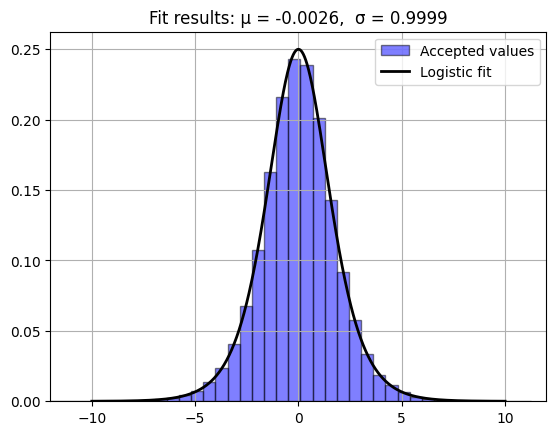

In [49]:
# define the plot
fig, ax = plt.subplots()

# plot the histogram
ax.hist(accepted, bins=40,  density=True, label='Accepted values', color='blue', edgecolor='black', alpha=0.5)

# set x-axis limit
xmin, xmax = plt.xlim((-12,12))

# 'h' variable for the x-axis
h = np.linspace(-10, 10, 1000)

# 'loplot' generate logistic pdf
loplot = logistic.pdf(h, p1, p2)

# plot logistic pdf
ax.plot(h, loplot, 'k', linewidth=2, label='Logistic fit')

# insert plot title
plt.title('Fit results: μ = %.4f,  σ = %.4f' % (p1, p2))

# generate legend
ax.legend()

# plot grid
ax.grid()

# show plot
plt.show()